# Model Building

In [57]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier,plot_tree

from joblib import dump,load

from sklearn.metrics import accuracy_score,balanced_accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

import matplotlib.pyplot as plt


## 
- ---

## Preprocessing

In [ ]:
df = pd.read_csv(r"..\data\MultiClassData.csv")


In [8]:
X = df.drop(columns=['Class'])
y = df['Class']
print(f"X shape: {X.shape} \ny shape: {y.shape} \n")




X shape: (5100, 9) 
y shape: (5100,) 



In [10]:
X_train_val,X_test,y_train_val,y_test = train_test_split(X,y,test_size=0.15,stratify=y,random_state=42)
X_train,X_val,y_train,y_val = train_test_split(X_train_val,y_train_val,test_size=0.17647,stratify=y_train_val,random_state=42)

print(f"X_train shape : {X_train.shape} \ny_train shape : {y_train.shape} \nX_test shape : {X_test.shape} \ny_test shape :{y_test.shape} \nX_val shape {X_val.shape} \ny_val shape {y_val.shape}")


X_train shape : (3570, 9) 
y_train shape : (3570,) 
X_test shape : (765, 9) 
y_test shape :(765,) 
X_val shape (765, 9) 
y_val shape (765,)


In [11]:
print("Train:")
print(y_train.value_counts().sort_index())

print("\nValidation:")
print(y_val.value_counts().sort_index())

print("\nTest:")
print(y_test.value_counts().sort_index())


Train:
Class
0      50
1     118
2     192
3    2690
4     520
Name: count, dtype: int64

Validation:
Class
0     11
1     25
2     41
3    577
4    111
Name: count, dtype: int64

Test:
Class
0     11
1     25
2     41
3    577
4    111
Name: count, dtype: int64


## 
- ---

## Logistic Regression Model

### Creating Pipeline

In [ ]:
logistic_pipeline = Pipeline([
    
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(random_state=42))
])


### Fiting

In [17]:
logistic_pipeline.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](5,)","[0,1,2,3,4]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['pH','TDS','Turbidity',...,'COD(mg/L)','Chlorine','Sodium']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


### Prdiciting

In [18]:
y_val_pred = logistic_pipeline.predict(X_val)


### Accuracy

In [21]:
accuracy = accuracy_score(y_val, y_val_pred)
balanced_accuracy = balanced_accuracy_score(y_val, y_val_pred)
macro_precision = precision_score(y_val,y_val_pred,average = "macro")
macro_recall = recall_score(y_val,y_val_pred,average = "macro")
macro_f1 = f1_score(y_val,y_val_pred,average="macro")
weighted_f1 = f1_score(y_val,y_val_pred,average="weighted")

print("Accuracy:", accuracy)
print("Balanced Accuracy:", balanced_accuracy)
print("Macro Precision:", macro_precision)
print("Macro Recall:", macro_recall)
print("Macro F1:", macro_f1)
print("Weighted F1:", weighted_f1)



Accuracy: 0.9712418300653595
Balanced Accuracy: 0.8903366626164952
Macro Precision: 0.9287003149252702
Macro Recall: 0.8903366626164952
Macro F1: 0.907682608978704
Weighted F1: 0.9710341041215773


In [22]:
print(f"classification Report \n {classification_report(y_val,y_val_pred)}")


classification Report 
               precision    recall  f1-score   support

           0       1.00      0.82      0.90        11
           1       0.84      0.84      0.84        25
           2       0.88      0.88      0.88        41
           3       0.99      1.00      0.99       577
           4       0.94      0.92      0.93       111

    accuracy                           0.97       765
   macro avg       0.93      0.89      0.91       765
weighted avg       0.97      0.97      0.97       765



In [23]:
print(f"Confusion Matrix \n {confusion_matrix(y_val,y_val_pred)}")


Confusion Matrix 
 [[  9   0   0   0   2]
 [  0  21   2   0   2]
 [  0   0  36   2   3]
 [  0   2   0 575   0]
 [  0   2   3   4 102]]


In [25]:
misclassified = X_val[y_val != y_val_pred].copy()

misclassified["Actual"] = y_val[y_val != y_val_pred]
misclassified["Predicted"] = y_val_pred[y_val != y_val_pred]

print(misclassified)


            pH  TDS  Turbidity  Phospate  ...  Chlorine  Sodium  Actual  Predicted
1245  7.553670  753       1.58  0.005807  ...         2       3       4          3
1939  7.564717  779       3.59  0.004159  ...         1       6       1          4
2868  7.597224  880       1.24  0.005332  ...         2      18       4          2
63    7.600000  754       0.25  0.009273  ...         4       5       4          3
158   7.568742  895       1.41  0.009683  ...         4       2       4          2
2181  7.536837  906       1.84  0.023949  ...         1      15       2          4
1208  7.559467  892       2.27  0.004419  ...         2       7       1          2
96    7.500000  880       3.63  0.005960  ...         4       2       4          2
2088  7.517421  640       0.17  0.005117  ...         3      17       4          1
508   7.573147  694       4.01  0.000802  ...         3      19       3          1
1051  7.518649  893       3.46  0.002389  ...         4       6       1          2
2649

In [26]:
misclassified[
    misclassified["Actual"].isin([0, 3])
][
    ["Iron", "COD(mg/L)", "TDS", "Phospate",
     "pH", "Turbidity", "Nitrate", "Chlorine", "Sodium",
     "Actual", "Predicted"]
]


,Iron,COD(mg/L),TDS,Phospate,pH,Turbidity,Nitrate,Chlorine,Sodium,Actual,Predicted
508,0.394004,400,694,0.000802,7.573147,4.01,8,3,19,3,1
3932,0.402696,394,638,0.012360,7.500741,3.60,6,1,9,0,4
3103,0.408839,400,705,0.002110,7.512746,1.03,8,3,16,3,1
4013,0.400751,391,848,0.015291,7.547618,2.48,8,1,1,0,4


## 
- ---------------------------

## Decision Tree Model

### Pipeline

In [28]:
decision_tree_pipeline = Pipeline([
    ('model', DecisionTreeClassifier(random_state=42))

])


### Fiting

In [29]:
decision_tree_pipeline.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](5,)","[0,1,2,3,4]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['pH','TDS','Turbidity',...,'COD(mg/L)','Chlorine','Sodium']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'


### Prediciting

In [30]:
decision_tree_y_pred = decision_tree_pipeline.predict(X_val)


### Accuracy

In [31]:
accuracy = accuracy_score(y_val, decision_tree_y_pred)
balanced_accuracy = balanced_accuracy_score(y_val, decision_tree_y_pred)
macro_precision = precision_score(y_val,decision_tree_y_pred,average = "macro")
macro_recall = recall_score(y_val,decision_tree_y_pred,average = "macro")
macro_f1 = f1_score(y_val,decision_tree_y_pred,average="macro")
weighted_f1 = f1_score(y_val,decision_tree_y_pred,average="weighted")

print("Accuracy:", accuracy)
print("Balanced Accuracy:", balanced_accuracy)
print("Macro Precision:", macro_precision)
print("Macro Recall:", macro_recall)
print("Macro F1:", macro_f1)
print("Weighted F1:", weighted_f1)


Accuracy: 1.0
Balanced Accuracy: 1.0
Macro Precision: 1.0
Macro Recall: 1.0
Macro F1: 1.0
Weighted F1: 1.0


In [32]:
print(f"classification Report \n {classification_report(y_val,decision_tree_y_pred)}")


classification Report 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      1.00      1.00        25
           2       1.00      1.00      1.00        41
           3       1.00      1.00      1.00       577
           4       1.00      1.00      1.00       111

    accuracy                           1.00       765
   macro avg       1.00      1.00      1.00       765
weighted avg       1.00      1.00      1.00       765



In [34]:
print(f"confusion_matrix \n {confusion_matrix(y_val,decision_tree_y_pred)}")


confusion_matrix 
 [[ 11   0   0   0   0]
 [  0  25   0   0   0]
 [  0   0  41   0   0]
 [  0   0   0 577   0]
 [  0   0   0   0 111]]


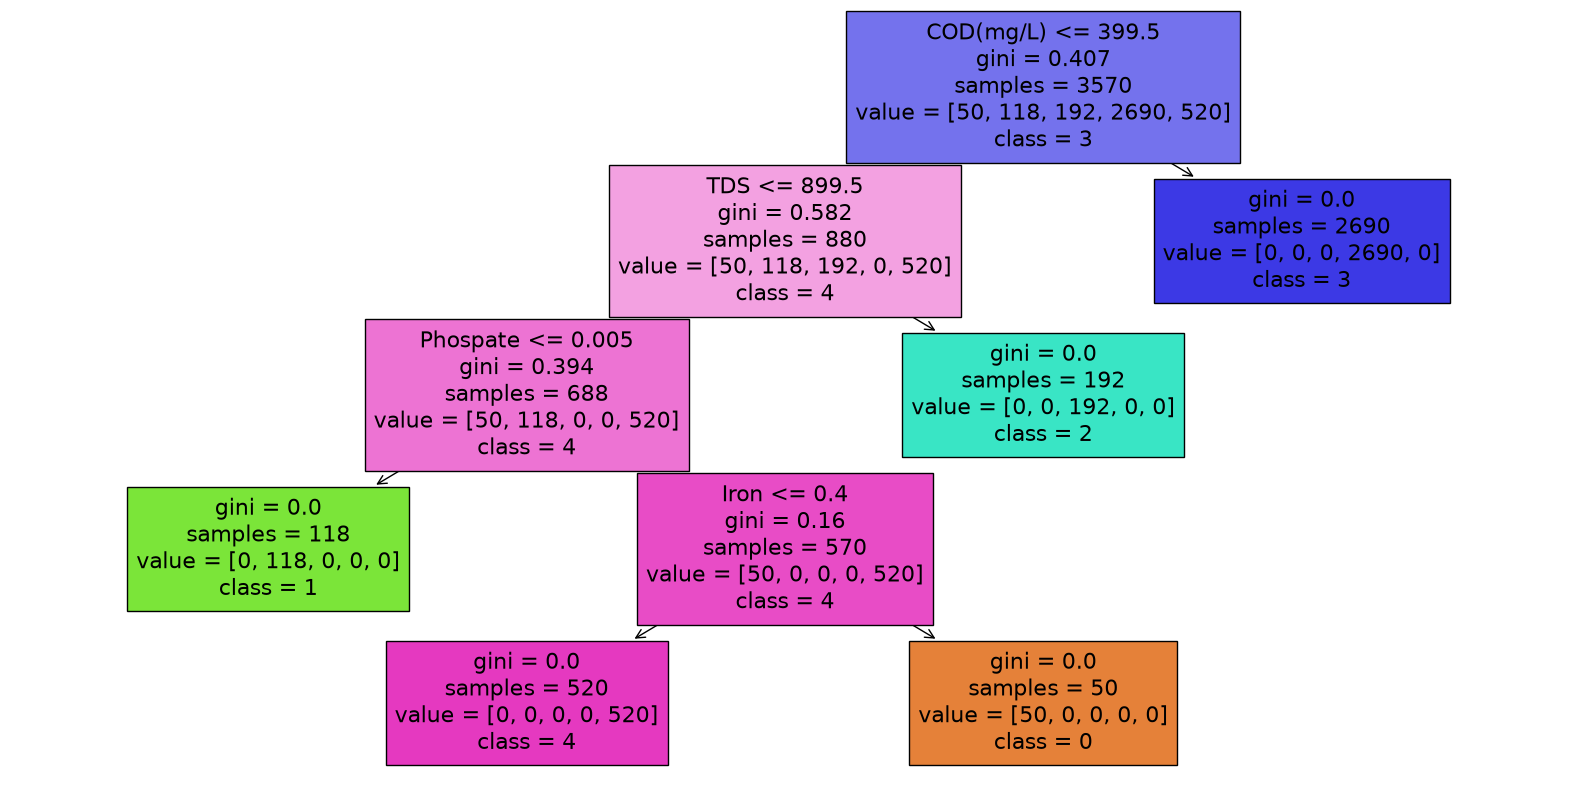

In [38]:
decision_tree = decision_tree_pipeline.named_steps["model"]

plt.figure(figsize=(20, 10))

plot_tree(
    decision_tree,
    feature_names=X_train.columns,
    class_names=[str(c) for c in sorted(y_train.unique())],
    filled=True
)

plt.show()


## 
- ------

## Random Forest Model

### Pipeline

In [48]:
rf_pipeline = Pipeline([
    ('model',RandomForestClassifier(random_state=42))

])




### Fit

In [49]:
rf_pipeline.fit(X_train,y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](5,)","[0,1,2,3,4]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['pH','TDS','Turbidity',...,'COD(mg/L)','Chlorine','Sodium']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'


### predict

In [50]:
rf_y_val_pred = rf_pipeline.predict(X_val)


### Accuracy

In [51]:
accuracy = accuracy_score(y_val, rf_y_val_pred)
balanced_accuracy = balanced_accuracy_score(y_val, rf_y_val_pred)
macro_precision = precision_score(y_val,rf_y_val_pred,average = "macro")
macro_recall = recall_score(y_val,rf_y_val_pred,average = "macro")
macro_f1 = f1_score(y_val,rf_y_val_pred,average="macro")
weighted_f1 = f1_score(y_val,rf_y_val_pred,average="weighted")

print("Accuracy:", accuracy)
print("Balanced Accuracy:", balanced_accuracy)
print("Macro Precision:", macro_precision)
print("Macro Recall:", macro_recall)
print("Macro F1:", macro_f1)
print("Weighted F1:", weighted_f1)


Accuracy: 1.0
Balanced Accuracy: 1.0
Macro Precision: 1.0
Macro Recall: 1.0
Macro F1: 1.0
Weighted F1: 1.0


##
- ------

## XGboost Classifier Model

### Pipeline 

In [58]:
xgb_pipeline = Pipeline([
    ("model",XGBClassifier(
      objective = 'multi:softprob',
      num_class = 5,
      eval_metrics = 'mlogloss',
      random_state = 42  
        
    ))
])


### Fit

In [59]:
xgb_pipeline.fit(X_train,y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](5,)","[0,1,2,3,4]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[<U9](9,)","['pH','TDS','Turbidity',...,'COD(mg/L)','Chlorine','Sodium']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"objective objective: typing.Union[str, xgboost.objective.Objective, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None


### Prediciting

In [ ]:
xgb_y_pred = xgb_pipeline.predict(X_val)


### Accuracy

In [61]:
accuracy = accuracy_score(y_val, xgb_y_pred)
balanced_accuracy = balanced_accuracy_score(y_val, xgb_y_pred)
macro_precision = precision_score(y_val,xgb_y_pred,average = "macro")
macro_recall = recall_score(y_val,xgb_y_pred,average = "macro")
macro_f1 = f1_score(y_val,xgb_y_pred,average="macro")
weighted_f1 = f1_score(y_val,xgb_y_pred,average="weighted")

print("Accuracy:", accuracy)
print("Balanced Accuracy:", balanced_accuracy)
print("Macro Precision:", macro_precision)
print("Macro Recall:", macro_recall)
print("Macro F1:", macro_f1)
print("Weighted F1:", weighted_f1)


Accuracy: 1.0
Balanced Accuracy: 1.0
Macro Precision: 1.0
Macro Recall: 1.0
Macro F1: 1.0
Weighted F1: 1.0


In [62]:
print(f"classification report \n {classification_report(y_val,xgb_y_pred)}")


classification report 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      1.00      1.00        25
           2       1.00      1.00      1.00        41
           3       1.00      1.00      1.00       577
           4       1.00      1.00      1.00       111

    accuracy                           1.00       765
   macro avg       1.00      1.00      1.00       765
weighted avg       1.00      1.00      1.00       765



In [63]:
print(f"confusion matrix : \n {confusion_matrix(y_val,xgb_y_pred)}")


confusion matrix : 
 [[ 11   0   0   0   0]
 [  0  25   0   0   0]
 [  0   0  41   0   0]
 [  0   0   0 577   0]
 [  0   0   0   0 111]]


##
- ------

## CatBoost Classifier Model

### Pipeline

In [69]:
catb_pipeline = Pipeline([
    ('model', CatBoostClassifier(verbose=True, loss_function='MultiClass', random_state=42))

])


### Fiting

In [ ]:
catb_pipeline.fit(X_train,y_train)


### Prediciting

In [ ]:
catb_y_pred = catb_pipeline.predict(X_val)


### Accuracy

In [72]:
accuracy = accuracy_score(y_val, catb_y_pred)
balanced_accuracy = balanced_accuracy_score(y_val, catb_y_pred)
macro_precision = precision_score(y_val,catb_y_pred,average = "macro")
macro_recall = recall_score(y_val,catb_y_pred,average = "macro")
macro_f1 = f1_score(y_val,catb_y_pred,average="macro")
weighted_f1 = f1_score(y_val,catb_y_pred,average="weighted")

print("Accuracy:", accuracy)
print("Balanced Accuracy:", balanced_accuracy)
print("Macro Precision:", macro_precision)
print("Macro Recall:", macro_recall)
print("Macro F1:", macro_f1)
print("Weighted F1:", weighted_f1)


Accuracy: 0.996078431372549
Balanced Accuracy: 0.9822439024390244
Macro Precision: 0.9914601769911504
Macro Recall: 0.9822439024390244
Macro F1: 0.9867252456538171
Weighted F1: 0.9960525568251992


In [ ]:
print(f"confusion matrix \n {confusion_matrix(y_val,catb_y_pred)}")
print(f"classification report \n {classification_report(y_val,catb_y_pred)}")


confusion matrix 
 [[ 11   0   0   0   0]
 [  0  24   1   0   0]
 [  0   0  39   0   2]
 [  0   0   0 577   0]
 [  0   0   0   0 111]]
classification report 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      0.96      0.98        25
           2       0.97      0.95      0.96        41
           3       1.00      1.00      1.00       577
           4       0.98      1.00      0.99       111

    accuracy                           1.00       765
   macro avg       0.99      0.98      0.99       765
weighted avg       1.00      1.00      1.00       765



In [ ]:
catb_y_pred = catb_y_pred.ravel()


In [ ]:
misclassified = X_val[y_val != catb_y_pred].copy()

misclassified["Actual"] = y_val[y_val != catb_y_pred]
misclassified["Predicted"] = catb_y_pred[y_val != catb_y_pred]

misclassified


,pH,TDS,Turbidity,Phospate,Nitrate,Iron,COD(mg/L),Chlorine,Sodium,Actual,Predicted
4320,7.531865,899,1.45,0.003654,6,0.385493,397,4,20,1,2
3441,7.522497,900,2.39,0.016482,8,0.348826,399,3,15,2,4
201,7.540083,900,1.59,0.028440,8,0.371939,391,4,12,2,4


## 
- --

## Test

### Logistic Regression

In [41]:
logisiticregression_test_pred = logistic_pipeline.predict(X_test)

# Accuracy Score 

print(f"accuracy Score \n {accuracy_score(y_test,logisiticregression_test_pred)}")
print(f"Balanced Accuracy Score \n {balanced_accuracy_score(y_test,logisiticregression_test_pred)}")
print(f"Macro Preciosn Score \n {precision_score(y_test,logisiticregression_test_pred,average='macro')}")
print(f"Macro Recall Score  \n {recall_score(y_test,logisiticregression_test_pred,average='macro')}")
print(f"Macro F1 Score  \n {f1_score(y_test,logisiticregression_test_pred,average='macro')}")
print(f"Weighted Macro Score \n {precision_score(y_test,logisiticregression_test_pred,average='weighted')}")


accuracy Score 
 0.9673202614379085
Balanced Accuracy Score 
 0.8774025089737142
Macro Preciosn Score 
 0.9326929249087448
Macro Recall Score  
 0.8774025089737142
Macro F1 Score  
 0.9000210528516638
Weighted Macro Score 
 0.9675485541402407


In [42]:
print("Confusion Matrix \n",confusion_matrix(y_test,logisiticregression_test_pred))
print("Classification Report \n",classification_report(y_test,logisiticregression_test_pred))


Confusion Matrix 
 [[  8   0   0   0   3]
 [  0  20   0   2   3]
 [  0   1  39   1   0]
 [  0   1   5 571   0]
 [  0   1   1   7 102]]
Classification Report 
               precision    recall  f1-score   support

           0       1.00      0.73      0.84        11
           1       0.87      0.80      0.83        25
           2       0.87      0.95      0.91        41
           3       0.98      0.99      0.99       577
           4       0.94      0.92      0.93       111

    accuracy                           0.97       765
   macro avg       0.93      0.88      0.90       765
weighted avg       0.97      0.97      0.97       765



### Decision Tree 

In [43]:
decision_tree_test_pred = decision_tree_pipeline.predict(X_test)

print(f"accuracy Score \n {accuracy_score(y_test,decision_tree_test_pred)}")
print(f"Balanced Accuracy Score \n {balanced_accuracy_score(y_test,decision_tree_test_pred)}")
print(f"Macro Preciosn Score \n {precision_score(y_test,decision_tree_test_pred,average='macro')}")
print(f"Macro Recall Score  \n {recall_score(y_test,decision_tree_test_pred,average='macro')}")
print(f"Macro F1 Score  \n {f1_score(y_test,decision_tree_test_pred,average='macro')}")
print(f"Weighted Macro Score \n {precision_score(y_test,decision_tree_test_pred,average='weighted')}")


accuracy Score 
 1.0
Balanced Accuracy Score 
 1.0
Macro Preciosn Score 
 1.0
Macro Recall Score  
 1.0
Macro F1 Score  
 1.0
Weighted Macro Score 
 1.0


In [44]:
print(f"Confusion Matrix \n {confusion_matrix(y_test,decision_tree_test_pred)}")


Confusion Matrix 
 [[ 11   0   0   0   0]
 [  0  25   0   0   0]
 [  0   0  41   0   0]
 [  0   0   0 577   0]
 [  0   0   0   0 111]]


In [45]:
print(f"Classification Report \n {classification_report(y_test,decision_tree_test_pred)}")


Classification Report 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      1.00      1.00        25
           2       1.00      1.00      1.00        41
           3       1.00      1.00      1.00       577
           4       1.00      1.00      1.00       111

    accuracy                           1.00       765
   macro avg       1.00      1.00      1.00       765
weighted avg       1.00      1.00      1.00       765



In [46]:
tree = decision_tree_pipeline.named_steps["model"]

print("Depth:", tree.get_depth())
print("Number of leaves:", tree.get_n_leaves())
print("Number of nodes:", tree.tree_.node_count)


Depth: 4
Number of leaves: 5
Number of nodes: 9


### Rndom Forest

In [53]:
rf_y_test_pred = rf_pipeline.predict(X_test)
print(f"accuracy Score \n {accuracy_score(y_test,rf_y_test_pred)}")
print(f"Balanced Accuracy Score \n {balanced_accuracy_score(y_test,rf_y_test_pred)}")
print(f"Macro Preciosn Score \n {precision_score(y_test,rf_y_test_pred,average='macro')}")
print(f"Macro Recall Score  \n {recall_score(y_test,rf_y_test_pred,average='macro')}")
print(f"Macro F1 Score  \n {f1_score(y_test,rf_y_test_pred,average='macro')}")
print(f"Weighted Macro Score \n {precision_score(y_test,rf_y_test_pred,average='weighted')}")


accuracy Score 
 0.9986928104575163
Balanced Accuracy Score 
 0.992
Macro Preciosn Score 
 0.9982142857142857
Macro Recall Score  
 0.992
Macro F1 Score  
 0.9950215063603917
Weighted Macro Score 
 0.9987044817927171


In [54]:
print(f"Classification Report \n {classification_report(y_test,rf_y_test_pred)}")


Classification Report 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      0.96      0.98        25
           2       1.00      1.00      1.00        41
           3       1.00      1.00      1.00       577
           4       0.99      1.00      1.00       111

    accuracy                           1.00       765
   macro avg       1.00      0.99      1.00       765
weighted avg       1.00      1.00      1.00       765



In [55]:
print(f"Confusion Matrix \n {confusion_matrix(y_test,rf_y_test_pred)}")



Confusion Matrix 
 [[ 11   0   0   0   0]
 [  0  24   0   0   1]
 [  0   0  41   0   0]
 [  0   0   0 577   0]
 [  0   0   0   0 111]]


In [56]:
rf_misclassified = X_test[y_test != rf_y_test_pred].copy()

rf_misclassified["Actual"] = y_test[y_test != rf_y_test_pred]
rf_misclassified["Predicted"] = rf_y_test_pred[y_test != rf_y_test_pred]
rf_misclassified


,pH,TDS,Turbidity,Phospate,Nitrate,Iron,COD(mg/L),Chlorine,Sodium,Actual,Predicted
3953,7.556583,836,1.61,0.004987,8,0.351998,390,4,19,1,4


### XGB 

In [64]:
xgb_y_test_pred = rf_pipeline.predict(X_test)
print(f"accuracy Score \n {accuracy_score(y_test,xgb_y_test_pred)}")
print(f"Balanced Accuracy Score \n {balanced_accuracy_score(y_test,xgb_y_test_pred)}")
print(f"Macro Preciosn Score \n {precision_score(y_test,xgb_y_test_pred,average='macro')}")
print(f"Macro Recall Score  \n {recall_score(y_test,xgb_y_test_pred,average='macro')}")
print(f"Macro F1 Score  \n {f1_score(y_test,xgb_y_test_pred,average='macro')}")
print(f"Weighted Macro Score \n {precision_score(y_test,xgb_y_test_pred,average='weighted')}")


accuracy Score 
 0.9986928104575163
Balanced Accuracy Score 
 0.992
Macro Preciosn Score 
 0.9982142857142857
Macro Recall Score  
 0.992
Macro F1 Score  
 0.9950215063603917
Weighted Macro Score 
 0.9987044817927171


In [65]:
print(f"Classification Report \n {classification_report(y_test,xgb_y_test_pred)}")


Classification Report 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      0.96      0.98        25
           2       1.00      1.00      1.00        41
           3       1.00      1.00      1.00       577
           4       0.99      1.00      1.00       111

    accuracy                           1.00       765
   macro avg       1.00      0.99      1.00       765
weighted avg       1.00      1.00      1.00       765



In [66]:
print(f"confusion matrix \n {confusion_matrix(y_test,xgb_y_test_pred)}")


confusion matrix 
 [[ 11   0   0   0   0]
 [  0  24   0   0   1]
 [  0   0  41   0   0]
 [  0   0   0 577   0]
 [  0   0   0   0 111]]


In [74]:
xgb_misclassified = X_test[y_test != xgb_y_test_pred].copy()
xgb_misclassified["Actual"] = y_test[y_test != xgb_y_test_pred]
xgb_misclassified["Predicted"] = xgb_y_test_pred[y_test != xgb_y_test_pred]
xgb_misclassified


,pH,TDS,Turbidity,Phospate,Nitrate,Iron,COD(mg/L),Chlorine,Sodium,Actual,Predicted
3953,7.556583,836,1.61,0.004987,8,0.351998,390,4,19,1,4


### CAT BOost

In [81]:
catb_y_test_pred = rf_pipeline.predict(X_test)
print(f"accuracy Score \n {accuracy_score(y_test,catb_y_test_pred)}")
print(f"Balanced Accuracy Score \n {balanced_accuracy_score(y_test,catb_y_test_pred)}")
print(f"Macro Preciosn Score \n {precision_score(y_test,catb_y_test_pred,average='macro')}")
print(f"Macro Recall Score  \n {recall_score(y_test,catb_y_test_pred,average='macro')}")
print(f"Macro F1 Score  \n {f1_score(y_test,catb_y_test_pred,average='macro')}")
print(f"Weighted Macro Score \n {precision_score(y_test,catb_y_test_pred,average='weighted')}")


accuracy Score 
 0.9986928104575163
Balanced Accuracy Score 
 0.992
Macro Preciosn Score 
 0.9982142857142857
Macro Recall Score  
 0.992
Macro F1 Score  
 0.9950215063603917
Weighted Macro Score 
 0.9987044817927171


In [83]:
print("Classification Report : ")
print(classification_report(y_test,catb_y_test_pred))
print("Confusion matrix : ")
print(confusion_matrix(y_test,catb_y_test_pred))



Classification Report : 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      0.96      0.98        25
           2       1.00      1.00      1.00        41
           3       1.00      1.00      1.00       577
           4       0.99      1.00      1.00       111

    accuracy                           1.00       765
   macro avg       1.00      0.99      1.00       765
weighted avg       1.00      1.00      1.00       765

Confusion matrix : 
[[ 11   0   0   0   0]
 [  0  24   0   0   1]
 [  0   0  41   0   0]
 [  0   0   0 577   0]
 [  0   0   0   0 111]]


In [84]:
catb_misclassified = X_test[y_test != catb_y_test_pred].copy()
catb_misclassified["Actual"] = y_test[y_test != catb_y_test_pred]
catb_misclassified["Predicted"] = catb_y_test_pred[y_test != catb_y_test_pred]
catb_misclassified


,pH,TDS,Turbidity,Phospate,Nitrate,Iron,COD(mg/L),Chlorine,Sodium,Actual,Predicted
3953,7.556583,836,1.61,0.004987,8,0.351998,390,4,19,1,4


## 
- -----

## Random Test

In [94]:
sample = X_test.sample(n=1, random_state=42)

sample_index = sample.index[0]
actual_class = y_test.loc[sample_index]

print("Sample:")
print(sample)

print("\nActual Class:", actual_class)


Sample:
           pH  TDS  Turbidity  Phospate  ...      Iron  COD(mg/L)  Chlorine  Sodium
126  7.528887  786        3.7  0.001435  ...  0.317139        393         1       7

[1 rows x 9 columns]

Actual Class: 1


In [ ]:
print("Logistic Regression:", logistic_pipeline.predict(sample)[0])
print("Decision Tree:", decision_tree_pipeline.predict(sample)[0])
print("Random Forest:", rf_pipeline.predict(sample)[0])
print("XGBoost:", xgb_pipeline.predict(sample)[0])
print("CatBoost:", catb_pipeline.predict(sample).ravel()[0])


Logistic Regression: 1
Decision Tree: 1
Random Forest: 1
XGBoost: 1
CatBoost: 1


In [ ]:
lr_pred = logistic_pipeline.predict(X_test)
dt_pred = decision_tree_pipeline.predict(X_test)
rf_pred = rf_pipeline.predict(X_test)
xgb_pred = xgb_pipeline.predict(X_test)
cat_pred = catb_pipeline.predict(X_test).ravel()


In [ ]:
comparison = X_test.copy()

comparison["Actual"] = y_test
comparison["Logistic"] = lr_pred
comparison["Decision Tree"] = dt_pred
comparison["Random Forest"] = rf_pred
comparison["XGBoost"] = xgb_pred
comparison["CatBoost"] = cat_pred


In [98]:
model_columns = [
    "Logistic",
    "Decision Tree",
    "Random Forest",
    "XGBoost",
    "CatBoost"
]

disagreement = comparison[
    comparison[model_columns].nunique(axis=1) > 1
]


In [ ]:
disagreement[
    ["Actual"] + model_columns
]


,Actual,Logistic,Decision Tree,Random Forest,XGBoost,CatBoost
4881,1,4,1,1,1,1
2159,4,1,4,4,4,4
2116,4,3,4,4,4,4
4714,1,3,1,1,1,1
1646,3,1,3,3,3,3
4626,3,2,3,3,3,3
2710,2,3,2,2,2,2
1481,0,4,0,0,0,0
4584,3,2,3,3,3,3
894,3,2,3,3,3,3


In [ ]:
disagreement.loc[
    disagreement.index[0],
    X_test.columns
]


pH             7.520272
TDS          760.000000
Turbidity      3.830000
Phospate       0.004830
Nitrate        8.000000
Iron           0.354985
COD(mg/L)    398.000000
Chlorine       1.000000
Sodium         8.000000
Name: 4881, dtype: float64

##
----

In [102]:
dump(logistic_pipeline, "../models/logistic_regression.joblib")
dump(decision_tree_pipeline, "../models/decision_tree.joblib")
dump(rf_pipeline, "../models/random_forest.joblib")
dump(xgb_pipeline, "../models/xgboost.joblib")
dump(catb_pipeline, "../models/catboost.joblib")


['../models/catboost.joblib']